In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u
from astropy import constants as const

In [2]:
df = pd.read_csv("solar_system.csv")
df = df.set_index("Attribute").T
df.index.name = "Planet"
df.reset_index(inplace=True)
df.columns.name = None
df

,Planet,Mass (10^24kg),Diameter (km),Density (kg/m^3),Gravity (m/s^2),Escape Velocity (km/s),Rotation Period (hours),Length of Day (hours),Distance from Sun (10^6 km),Perihelion (10^6 km),...,Orbital Period (days),Orbital Velocity (km/s),Orbital Inclination (deg),Orbital Eccentricity,Obliquity to Orbit (deg),Mean Temperature (C),Surface Pressure (bars),Number of Moons,Ring System?,Global Magnetic Field?
0,Mercury,0.330,4879,5429,3.7,4.3,1407.6,4222.6,57.9,46.0,...,88.0,47.4,7.0,0.206,0.034,167,0,0,No,Yes
1,Venus,4.87,12104,5243,8.9,10.4,-5832.5,2802.0,108.2,107.5,...,224.7,35.0,3.4,0.007,177.4,464,92,0,No,No
2,Earth,5.97,12756,5514,9.8,11.2,23.9,24.0,149.6,147.1,...,365.2,29.8,0.0,0.017,23.4,15,1,1,No,Yes
3,Moon,0.073,3475,3340,1.6,2.4,655.7,708.7,0.384,0.363,...,27.3,1.0,5.1,0.055,6.7,-20,0,0,No,No
4,Mars,0.642,6792,3934,3.7,5.0,24.6,24.7,228.0,206.7,...,687.0,24.1,1.8,0.094,25.2,-65,0.01,2,No,No
5,Jupiter,1898,142984,1326,23.1,59.5,9.9,9.9,778.5,740.6,...,4331,13.1,1.3,0.049,3.1,-110,Unknown,95,Yes,Yes
6,Saturn,568,120536,687,9.0,35.5,10.7,10.7,1432.0,1357.6,...,10747,9.7,2.5,0.052,26.7,-140,Unknown,274,Yes,Yes
7,Uranus,86.8,51118,1270,8.7,21.3,-17.2,17.2,2867.0,2732.7,...,30589,6.8,0.8,0.047,97.8,-195,Unknown,28,Yes,Yes
8,Neptune,102,49528,1638,11.0,23.5,16.1,16.1,4515.0,4471.1,...,59800,5.4,1.8,0.010,28.3,-200,Unknown,16,Yes,Yes
9,Pluto,0.0130,2376,1850,0.7,1.3,-153.3,153.3,5906.4,4436.8,...,90560,4.7,17.2,0.244,119.5,-225,0.00001,5,No,Unknown


In [3]:
#Before: 20 rows × 11 columns
#After: 10 rows × 21 columns
#df = pd.read_csv("solar_system.csv")
#Loads the CSV into a pandas DataFrame.

#df = df.set_index("Attribute").T
#Makes the “Attribute” column the index, then transposes the table so planets become rows.

#df.index.name = "Planet"
#Renames the index to “Planet”.

#df.reset_index(inplace=True)
#Turns the index (“Planet”) back into a normal column.

#df.columns.name = None
#Removes the automatic column group name that pandas adds.

#I had 10 objects in the csv file
#So after transposing, I get 10 rows and not 11.

#Also, the original dataset has 20 attributes, and when transposed + adding the “Planet” column, I get 21 columns not 20

In [4]:
print(df.columns)


Index(['Planet', 'Mass (10^24kg)', 'Diameter (km)', 'Density (kg/m^3)',
       'Gravity (m/s^2)', 'Escape Velocity (km/s)', 'Rotation Period (hours)',
       'Length of Day (hours)', 'Distance from Sun (10^6 km)',
       'Perihelion (10^6 km)', 'Aphelion (10^6 km)', 'Orbital Period (days)',
       'Orbital Velocity (km/s)', 'Orbital Inclination (deg)',
       'Orbital Eccentricity', 'Obliquity to Orbit (deg)',
       'Mean Temperature (C)', 'Surface Pressure (bars)', 'Number of Moons',
       'Ring System?', 'Global Magnetic Field?'],
      dtype='object')


In [5]:
#---With units---

#Mass (10^24kg)

#Diameter (km)

#Density (kg/m^3)

#Gravity (m/s^2)

#Escape Velocity (km/s)

#Rotation Period (hours)

#Length of Day (hours)

#Distance from Sun (10^6 km)

#Perihelion (10^6 km)

#Aphelion (10^6 km)

#Orbital Period (days)

#Orbital Velocity (km/s)

#Orbital Inclination (deg)

#Obliquity to Orbit (deg)

#Mean Temperature (C)

#Surface Pressure (bars)

#---Without units---

#Planet

#Orbital Eccentricity

#Number of Moons

#Ring System?

#Global Magnetic Field?

In [6]:
df.dtypes

Planet                         object
Mass (10^24kg)                 object
Diameter (km)                  object
Density (kg/m^3)               object
Gravity (m/s^2)                object
Escape Velocity (km/s)         object
Rotation Period (hours)        object
Length of Day (hours)          object
Distance from Sun (10^6 km)    object
Perihelion (10^6 km)           object
Aphelion (10^6 km)             object
Orbital Period (days)          object
Orbital Velocity (km/s)        object
Orbital Inclination (deg)      object
Orbital Eccentricity           object
Obliquity to Orbit (deg)       object
Mean Temperature (C)           object
Surface Pressure (bars)        object
Number of Moons                object
Ring System?                   object
Global Magnetic Field?         object
dtype: object

In [7]:
for col in df.columns:
    print(col, df[col].apply(type).unique())

Planet [<class 'str'>]
Mass (10^24kg) [<class 'str'>]
Diameter (km) [<class 'str'>]
Density (kg/m^3) [<class 'str'>]
Gravity (m/s^2) [<class 'str'>]
Escape Velocity (km/s) [<class 'str'>]
Rotation Period (hours) [<class 'str'>]
Length of Day (hours) [<class 'str'>]
Distance from Sun (10^6 km) [<class 'str'>]
Perihelion (10^6 km) [<class 'str'>]
Aphelion (10^6 km) [<class 'str'>]
Orbital Period (days) [<class 'str'>]
Orbital Velocity (km/s) [<class 'str'>]
Orbital Inclination (deg) [<class 'str'>]
Orbital Eccentricity [<class 'str'>]
Obliquity to Orbit (deg) [<class 'str'>]
Mean Temperature (C) [<class 'str'>]
Surface Pressure (bars) [<class 'str'>]
Number of Moons [<class 'str'>]
Ring System? [<class 'str'>]
Global Magnetic Field? [<class 'str'>]


In [8]:
#The actual values in every column are strings.
#Storing numbers as strings is a problem because Python cannot do math on strings. 

In [9]:
for col in df.columns:
    if col not in ["Planet", "Ring System?", "Global Magnetic Field?"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df.dtypes

Planet                          object
Mass (10^24kg)                 float64
Diameter (km)                    int64
Density (kg/m^3)                 int64
Gravity (m/s^2)                float64
Escape Velocity (km/s)         float64
Rotation Period (hours)        float64
Length of Day (hours)          float64
Distance from Sun (10^6 km)    float64
Perihelion (10^6 km)           float64
Aphelion (10^6 km)             float64
Orbital Period (days)          float64
Orbital Velocity (km/s)        float64
Orbital Inclination (deg)      float64
Orbital Eccentricity           float64
Obliquity to Orbit (deg)       float64
Mean Temperature (C)             int64
Surface Pressure (bars)        float64
Number of Moons                  int64
Ring System?                    object
Global Magnetic Field?          object
dtype: object

In [10]:
#object
#float64
#int64
#1. float64
#A 64-bit floating point number.
#Used for numbers with decimals.
#2. int64
#A 64-bit integer.
#Whole numbers with no decimals.
#3. object
#A general Python object type.
#Usually means the column still contains strings.

#The three remaining object-type columns are “Planet”, “Ring System?”, 
#and “Global Magnetic Field?” because they contain text instead of numbers

In [11]:
def attach_units(col, unit, new_name):
    df[col] = df[col] * unit
    df.rename(columns={col: new_name}, inplace = True)

attach_units("Mass (10^24kg)", 1e24 * u.kg, "Mass (kg)")
df["Mass (kg)"]


0    3.300000e+23
1    4.870000e+24
2    5.970000e+24
3    7.300000e+22
4    6.420000e+23
5    1.898000e+27
6    5.680000e+26
7    8.680000e+25
8    1.020000e+26
9    1.300000e+22
Name: Mass (kg), dtype: float64

In [12]:
df["Semi-major Axis (10^6 km)"] = (df["Perihelion (10^6 km)"] + df["Aphelion (10^6 km)"]) / 2
df

,Planet,Mass (kg),Diameter (km),Density (kg/m^3),Gravity (m/s^2),Escape Velocity (km/s),Rotation Period (hours),Length of Day (hours),Distance from Sun (10^6 km),Perihelion (10^6 km),...,Orbital Velocity (km/s),Orbital Inclination (deg),Orbital Eccentricity,Obliquity to Orbit (deg),Mean Temperature (C),Surface Pressure (bars),Number of Moons,Ring System?,Global Magnetic Field?,Semi-major Axis (10^6 km)
0,Mercury,3.300000e+23,4879,5429,3.7,4.3,1407.6,4222.6,57.900,46.000,...,47.4,7.0,0.206,0.034,167,0.00000,0,No,Yes,57.9000
1,Venus,4.870000e+24,12104,5243,8.9,10.4,-5832.5,2802.0,108.200,107.500,...,35.0,3.4,0.007,177.400,464,92.00000,0,No,No,108.2000
2,Earth,5.970000e+24,12756,5514,9.8,11.2,23.9,24.0,149.600,147.100,...,29.8,0.0,0.017,23.400,15,1.00000,1,No,Yes,149.6000
3,Moon,7.300000e+22,3475,3340,1.6,2.4,655.7,708.7,0.384,0.363,...,1.0,5.1,0.055,6.700,-20,0.00000,0,No,No,0.3845
4,Mars,6.420000e+23,6792,3934,3.7,5.0,24.6,24.7,228.000,206.700,...,24.1,1.8,0.094,25.200,-65,0.01000,2,No,No,228.0000
5,Jupiter,1.898000e+27,142984,1326,23.1,59.5,9.9,9.9,778.500,740.600,...,13.1,1.3,0.049,3.100,-110,NaN,95,Yes,Yes,778.5000
6,Saturn,5.680000e+26,120536,687,9.0,35.5,10.7,10.7,1432.000,1357.600,...,9.7,2.5,0.052,26.700,-140,NaN,274,Yes,Yes,1432.0500
7,Uranus,8.680000e+25,51118,1270,8.7,21.3,-17.2,17.2,2867.000,2732.700,...,6.8,0.8,0.047,97.800,-195,NaN,28,Yes,Yes,2867.0500
8,Neptune,1.020000e+26,49528,1638,11.0,23.5,16.1,16.1,4515.000,4471.100,...,5.4,1.8,0.010,28.300,-200,NaN,16,Yes,Yes,4515.0000
9,Pluto,1.300000e+22,2376,1850,0.7,1.3,-153.3,153.3,5906.400,4436.800,...,4.7,17.2,0.244,119.500,-225,0.00001,5,No,Unknown,5906.3500


In [13]:
days = df["Orbital Period (days)"].astype(float).to_numpy()
years = (days * u.day).to_value(u.year)
df["Orbital Period (years)"] = years
df["Orbital Period (years)"]

0      0.240931
1      0.615195
2      0.999863
3      0.074743
4      1.880903
5     11.857632
6     29.423682
7     83.748118
8    163.723477
9    247.939767
Name: Orbital Period (years), dtype: float64

In [14]:
value = df[df["Planet"]=="Earth"]["Orbital Period (years)"].iloc[0]
print(f"{value:.4f}")

0.9999


In [15]:
#An AU is the average distance between Earth and the Sun, 
#and Astropy converts kilometers to AU automatically.

In [16]:
const.au


<<class 'astropy.constants.iau2015.IAU2015'> name='Astronomical Unit' value=149597870700.0 uncertainty=0.0 unit='m' reference='IAU 2012 Resolution B2'>

In [17]:
(const.au.to(u.km))


<Quantity 1.49597871e+08 km>

In [18]:
diam = df["Diameter (km)"].astype(float).to_numpy()
df["Diameter (AU)"] = (diam * u.km).to_value(u.au)

dist = df["Distance from Sun (10^6 km)"].astype(float).to_numpy()
df["Distance from Sun (AU)"] = (dist * 1e6 * u.km).to_value(u.au)

peri = df["Perihelion (10^6 km)"].astype(float).to_numpy()
df["Perihelion (AU)"] = (peri * 1e6 * u.km).to_value(u.au)

aphe = df["Aphelion (10^6 km)"].astype(float).to_numpy()
df["Aphelion (AU)"] = (aphe * 1e6 * u.km).to_value(u.au)

semi = df["Semi-major Axis (10^6 km)"].astype(float).to_numpy()
df["Semi-major Axis (AU)"] = (semi * 1e6 * u.km).to_value(u.au)

planet = "Earth"
row = df[df["Planet"] == planet].iloc[0]

print("Diameter (AU):", row["Diameter (AU)"])
print("Distance from Sun (AU):", row["Distance from Sun (AU)"])
print("Perihelion (AU):", row["Perihelion (AU)"])
print("Aphelion (AU):", row["Aphelion (AU)"])
print("Semi-major Axis (AU):", row["Semi-major Axis (AU)"])


Diameter (AU): 8.526859333165629e-05
Distance from Sun (AU): 1.0000142334913595
Perihelion (AU): 0.9833027656856883
Aphelion (AU): 1.0167257012970305
Semi-major Axis (AU): 1.0000142334913595


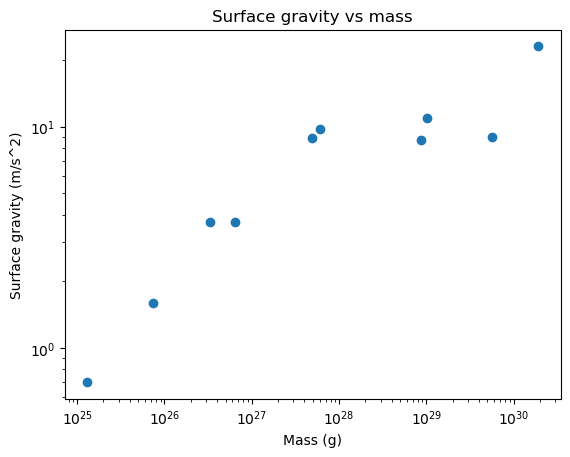

In [19]:
mass_kg = df["Mass (kg)"].astype(float).to_numpy()
mass_g = (mass_kg * u.kg).to_value(u.g)
g_vals = df["Gravity (m/s^2)"].astype(float).to_numpy()

plt.figure()
plt.loglog(mass_g, g_vals, "o")
plt.xlabel("Mass (g)")
plt.ylabel("Surface gravity (m/s^2)")
plt.title("Surface gravity vs mass")
plt.show()

Best-fit slope m: 0.2416184632394755
Best-fit intercept b: -5.968369855331557
Reduced chi-squared: 0.03536864165577379


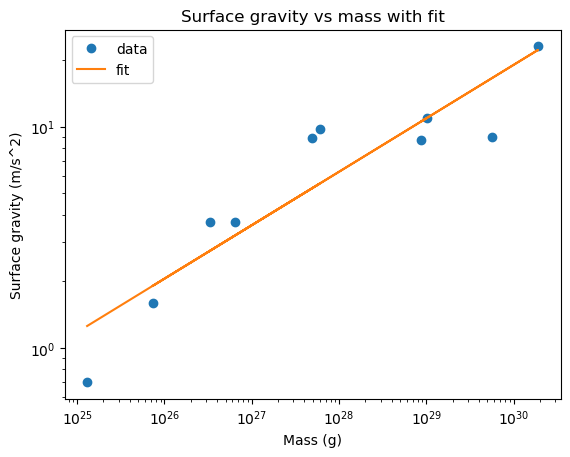

In [21]:
from scipy.optimize import curve_fit
x = np.log10(mass_g)
y = np.log10(g_vals)

def line(x, m, b):
    return m * x + b

popt, pcov = curve_fit(line, x, y)
m_fit, b_fit = popt

y_fit = line(x, m_fit, b_fit)

residuals = y - y_fit
dof = len(y) - len(popt)
chi2 = np.sum(residuals**2)
chi2_red = chi2 / dof

print("Best-fit slope m:", m_fit)
print("Best-fit intercept b:", b_fit)
print("Reduced chi-squared:", chi2_red)

g_fit = 10**y_fit

plt.figure()
plt.loglog(mass_g, g_vals, "o", label="data")
plt.loglog(mass_g, g_fit, label="fit")
plt.xlabel("Mass (g)")
plt.ylabel("Surface gravity (m/s^2)")
plt.title("Surface gravity vs mass with fit")
plt.legend()
plt.show()

In [23]:
df.to_csv("units.csv", index=False)